In [2]:
import pandas as pd

fact = pd.read_csv("fact_student_performance.csv")
stream = pd.read_csv("stream.csv")
subject = pd.read_csv("dim_subject.csv")
syllabus = pd.read_csv("syllabus.csv")

print("Fact records:", len(fact))
print("Streams:", len(stream))
print("Subjects:", len(subject))
print("Syllabus:", len(syllabus))

Fact records: 1012659
Streams: 8
Subjects: 62
Syllabus: 2


In [3]:
# Join fact table with dimension tables

olap_df = fact.merge(
    stream[['stream_key', 'stream_name']],
    on='stream_key',
    how='left'
)

olap_df = olap_df.merge(
    subject[['subject_key', 'subject_name']],
    on='subject_key',
    how='left'
)

olap_df = olap_df.merge(
    syllabus[['syllabus_key', 'syllabus_name']],
    on='syllabus_key',
    how='left'
)

# Display the result
print("OLAP dataset records:", len(olap_df))

olap_df.head()

OLAP dataset records: 1012659


,performance_key,student_key,subject_key,stream_key,exam_key,syllabus_key,grade,z_score,district_rank,island_rank,cgt_score,ge_grade,stream_name,subject_name,syllabus_name
0,1,2,56,8,1,1,S,-0.2648,4154.0,62338.0,32.0,C,ARTS,POLITICAL SCIENCE,New Syllabus
1,2,2,13,8,1,1,C,-0.2648,4154.0,62338.0,32.0,C,ARTS,CARNATIC MUSIC,New Syllabus
2,3,2,61,8,1,1,C,-0.2648,4154.0,62338.0,32.0,C,ARTS,TAMIL,New Syllabus
3,4,4,26,3,1,1,C,-0.1012,5678.0,30449.0,34.0,S,COMMERCE,ECONOMICS,New Syllabus
4,5,4,12,3,1,1,C,-0.1012,5678.0,30449.0,34.0,S,COMMERCE,BUSINESS STUDIES,New Syllabus


In [4]:
# Create OLAP Cube
# Dimensions: Stream × Subject × Syllabus
# Measure: Average Z-score

olap_cube = pd.pivot_table(
    olap_df,
    index=['stream_name', 'subject_name'],
    columns='syllabus_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP Cube created successfully!")
olap_cube.head(20)

OLAP Cube created successfully!


syllabus_name                              New Syllabus  Old Syllabus
stream_name subject_name                                             
ARTS        ACCOUNTING                         0.272855      0.084400
            AGRICULTURAL SCIENCE               0.494807      0.336200
            AGRO TECHNOLOGY                    0.525680      0.284221
            ARABIC                             0.509826      0.520633
            ART                                0.327864      0.322640
            BIO-RESOURCE TECHNOLOGY            0.405900      0.588125
            BUDDHISM                           0.357623      0.366428
            BUDDHIST CIVILIZATION              0.462640      0.470212
            BUSINESS STATISTICS                0.939150      2.293200
            CARNATIC MUSIC                     0.318326      0.289059
            CHINESE                            0.516951      0.723267
            CHRISTIAN CIVILIZATION             0.288468      0.358444
            CHRISTIANITY                       0.273246      0.160811
            CIVIL TECHNOLOGY                  -0.126075     -0.273720
            COMBINED MATHEMATICS               0.269500      0.533833
            COMMUNICATION & MEDIA STUDIES      0.445534      0.406448
            DANCING(BHARATHA)                  0.304591      0.347465
            DANCING(INDIGENOUS)                0.418700      0.440909
            DRAMA AND THEATRE (ENGLISH)        1.191150           NaN
            DRAMA AND THEATRE (SINHALA)        0.374190      0.326444

In [5]:
cube = olap_df.pivot_table(
    index='stream_name',
    columns=['subject_name', 'syllabus_name'],
    values='z_score',
    aggfunc='mean'
)

print("OLAP Cube Dimensions:")
print("Streams:", olap_df['stream_name'].nunique())
print("Subjects:", olap_df['subject_name'].nunique())
print("Syllabus:", olap_df['syllabus_name'].nunique())

cube.head()

OLAP Cube Dimensions:
Streams: 8
Subjects: 62
Syllabus: 2


subject_name             ACCOUNTING              AGRICULTURAL SCIENCE  \
syllabus_name          New Syllabus Old Syllabus         New Syllabus   
stream_name                                                             
ARTS                       0.272855     0.084400             0.494807   
BIOLOGICAL SCIENCE              NaN          NaN             0.420195   
BIOSYSTEMS TECHNOLOGY      0.857300          NaN             0.490985   
COMMERCE                   0.494503     0.655889             0.556780   
ENGINEERING TECHNOLOGY     0.601456          NaN             0.260880   

subject_name                        AGRO TECHNOLOGY                    ARABIC  \
syllabus_name          Old Syllabus    New Syllabus Old Syllabus New Syllabus   
stream_name                                                                     
ARTS                       0.336200         0.52568     0.284221     0.509826   
BIOLOGICAL SCIENCE         0.116601             NaN          NaN          NaN   
BIOSYSTEMS TECHNOLOGY      0.430225             NaN          NaN          NaN   
COMMERCE                   0.974600             NaN          NaN          NaN   
ENGINEERING TECHNOLOGY     0.392207             NaN          NaN          NaN   

subject_name                                 ART               ...  \
syllabus_name          Old Syllabus New Syllabus Old Syllabus  ...   
stream_name                                                    ...   
ARTS                       0.520633     0.327864      0.32264  ...   
BIOLOGICAL SCIENCE              NaN          NaN          NaN  ...   
BIOSYSTEMS TECHNOLOGY           NaN     0.509905      1.42320  ...   
COMMERCE                        NaN          NaN          NaN  ...   
ENGINEERING TECHNOLOGY          NaN     0.216899      0.10330  ...   

subject_name               SANSKRIT              SCIENCE FOR TECHNOLOGY  \
syllabus_name          New Syllabus Old Syllabus           New Syllabus   
stream_name                                                               
ARTS                        0.51633     0.647664                    NaN   
BIOLOGICAL SCIENCE              NaN          NaN                    NaN   
BIOSYSTEMS TECHNOLOGY           NaN          NaN               0.489908   
COMMERCE                        NaN          NaN                    NaN   
ENGINEERING TECHNOLOGY          NaN          NaN               0.462836   

subject_name                             SINHALA                     TAMIL  \
syllabus_name          Old Syllabus New Syllabus Old Syllabus New Syllabus   
stream_name                                                                  
ARTS                            NaN     0.465493     0.497721     0.386457   
BIOLOGICAL SCIENCE              NaN          NaN          NaN          NaN   
BIOSYSTEMS TECHNOLOGY      0.438325          NaN          NaN          NaN   
COMMERCE                        NaN          NaN          NaN          NaN   
ENGINEERING TECHNOLOGY     0.488243          NaN          NaN          NaN   

subject_name                        WESTERN MUSIC               
syllabus_name          Old Syllabus  New Syllabus Old Syllabus  
stream_name                                                     
ARTS                       0.367847      0.686107       0.7947  
BIOLOGICAL SCIENCE              NaN           NaN          NaN  
BIOSYSTEMS TECHNOLOGY           NaN           NaN          NaN  
COMMERCE                        NaN           NaN          NaN  
ENGINEERING TECHNOLOGY          NaN           NaN          NaN  

[5 rows x 115 columns]

In [6]:
# ============================================
# OLAP ROLL-UP
# Subject level → Stream level
# ============================================

rollup = olap_df.pivot_table(
    index='stream_name',
    columns='syllabus_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP Roll-up: Average Z-score by Stream and Syllabus")

rollup

OLAP Roll-up: Average Z-score by Stream and Syllabus


syllabus_name,New Syllabus,Old Syllabus
stream_name,,
ARTS,0.472719,0.452742
BIOLOGICAL SCIENCE,0.623262,0.525880
BIOSYSTEMS TECHNOLOGY,0.489908,0.438325
COMMERCE,0.494154,0.649063
ENGINEERING TECHNOLOGY,0.462836,0.488243
Non Stream,0.480401,0.353565
PHYSICAL SCIENCE,0.652077,0.437455
Unknown,-0.560624,-0.549774


In [7]:
# ============================================
# OLAP DRILL-DOWN
# Stream level → Subject level
# ============================================

drilldown = olap_df.pivot_table(
    index=['stream_name', 'subject_name'],
    values='z_score',
    aggfunc=['count', 'mean']
)

drilldown.columns = ['result_count', 'average_z_score']

print("OLAP Drill-down: Stream → Subject")
drilldown

OLAP Drill-down: Stream → Subject


result_count  average_z_score
stream_name subject_name                                         
ARTS        ACCOUNTING                        23         0.264661
            AGRICULTURAL SCIENCE            2997         0.479777
            AGRO TECHNOLOGY                  373         0.475835
            ARABIC                          1571         0.511243
            ART                             3625         0.327532
...                                          ...              ...
Unknown     SANSKRIT                         101        -0.627967
            SCIENCE FOR TECHNOLOGY          5712        -0.532301
            SINHALA                        10932        -0.653287
            TAMIL                           3111        -0.665572
            WESTERN MUSIC                     12        -0.566217

[218 rows x 2 columns]

In [8]:
# ============================================
# OLAP SLICE
# Select one Syllabus
# ============================================

slice_new = olap_df[
    olap_df['syllabus_name'] == 'New Syllabus'
]

slice_result = slice_new.pivot_table(
    index='stream_name',
    columns='subject_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP Slice: New Syllabus Only")

slice_result

OLAP Slice: New Syllabus Only


subject_name,ACCOUNTING,AGRICULTURAL SCIENCE,AGRO TECHNOLOGY,ARABIC,ART,BIO SYSTEMS TECHNOLOGY,BIO-RESOURCE TECHNOLOGY,BIOLOGY,BUDDHISM,BUDDHIST CIVILIZATION,...,ORIENTAL MUSIC,PALI,PHYSICS,POLITICAL SCIENCE,RUSSIAN,SANSKRIT,SCIENCE FOR TECHNOLOGY,SINHALA,TAMIL,WESTERN MUSIC
stream_name,,,,,,,,,,,,,,,,,,,,,
ARTS,0.272855,0.494807,0.525680,0.509826,0.327864,NaN,0.4059,NaN,0.357623,0.462640,...,0.456360,0.368567,NaN,0.508408,0.298182,0.516330,NaN,0.465493,0.386457,0.686107
BIOLOGICAL SCIENCE,NaN,0.420195,NaN,NaN,NaN,NaN,NaN,0.623262,NaN,NaN,...,NaN,NaN,0.635469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIOSYSTEMS TECHNOLOGY,0.857300,0.490985,NaN,NaN,0.509905,0.489908,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.489908,NaN,NaN,NaN
COMMERCE,0.494503,0.556780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.313550,NaN,NaN,NaN,NaN,NaN,NaN
ENGINEERING TECHNOLOGY,0.601456,0.260880,NaN,NaN,0.216899,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.462836,NaN,NaN,NaN
Non Stream,0.828224,0.383212,0.436307,-0.097820,-0.046220,0.110714,NaN,0.455723,0.003811,0.033689,...,-0.009536,-0.197667,0.634077,0.153700,-0.041800,0.073700,0.462850,0.017702,0.034946,0.208043
PHYSICAL SCIENCE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.652077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unknown,-0.660929,-0.449218,-0.439653,-0.631016,-0.708769,-0.573343,-0.1841,-0.395712,-0.719100,-0.641748,...,-0.708037,-0.742098,-0.418225,-0.611210,-0.938329,-0.626501,-0.536707,-0.648899,-0.676406,-0.566217


In [9]:
# ============================================
# OLAP DICE
# Multiple values from multiple dimensions
# ============================================

selected_streams = [
    'ARTS',
    'COMMERCE'
]

selected_subjects = [
    'ACCOUNTING',
    'ECONOMICS',
    'BUSINESS STUDIES'
]

dice_data = olap_df[
    olap_df['stream_name'].isin(selected_streams) &
    olap_df['subject_name'].isin(selected_subjects) &
    (olap_df['syllabus_name'] == 'New Syllabus')
]

dice_result = dice_data.groupby(
    ['stream_name', 'subject_name']
).agg(
    result_count=('z_score', 'count'),
    average_z_score=('z_score', 'mean')
).reset_index()

dice_result['average_z_score'] = dice_result['average_z_score'].round(4)

print("OLAP Dice: Selected Streams + Subjects + New Syllabus")

dice_result

OLAP Dice: Selected Streams + Subjects + New Syllabus


,stream_name,subject_name,result_count,average_z_score
0,ARTS,ACCOUNTING,22,0.2729
1,ARTS,ECONOMICS,4595,0.6717
2,COMMERCE,ACCOUNTING,39135,0.4945
3,COMMERCE,BUSINESS STUDIES,37210,0.4829
4,COMMERCE,ECONOMICS,36945,0.4945


In [10]:
# ============================================
# OLAP PIVOT
# Change the orientation of dimensions
# ============================================

pivot_result = olap_df.pivot_table(
    index='subject_name',
    columns='stream_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP Pivot: Subject × Stream")
pivot_result.round(4)

OLAP Pivot: Subject × Stream


stream_name,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,Non Stream,PHYSICAL SCIENCE,Unknown
subject_name,,,,,,,,
ACCOUNTING,0.2647,NaN,0.8573,0.4972,0.6015,0.7908,NaN,-0.6522
AGRICULTURAL SCIENCE,0.4798,0.3105,0.4877,0.6762,0.2641,0.3496,NaN,-0.4619
AGRO TECHNOLOGY,0.4758,NaN,NaN,NaN,NaN,0.3246,NaN,-0.4818
ARABIC,0.5112,NaN,NaN,NaN,NaN,-0.0694,NaN,-0.6003
ART,0.3275,NaN,0.5496,NaN,0.2140,-0.0208,NaN,-0.7096
...,...,...,...,...,...,...,...,...
SANSKRIT,0.5197,NaN,NaN,NaN,NaN,0.0737,NaN,-0.6280
SCIENCE FOR TECHNOLOGY,NaN,NaN,0.4875,NaN,0.4636,0.5103,NaN,-0.5323
SINHALA,0.4676,NaN,NaN,NaN,NaN,0.0219,NaN,-0.6533


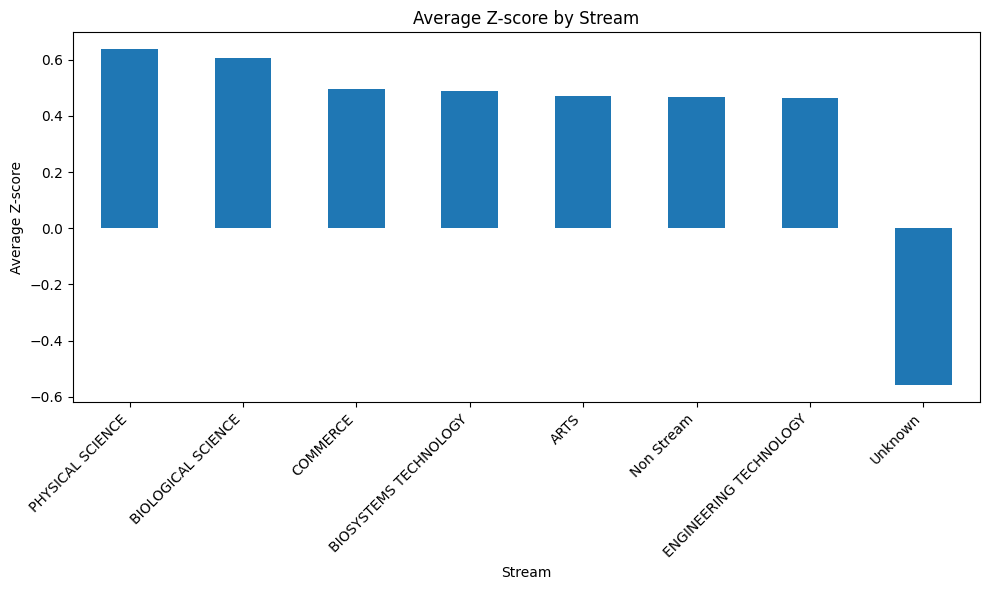

In [11]:
import matplotlib.pyplot as plt

stream_chart = olap_df.groupby('stream_name')['z_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
stream_chart.plot(kind='bar')
plt.title('Average Z-score by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

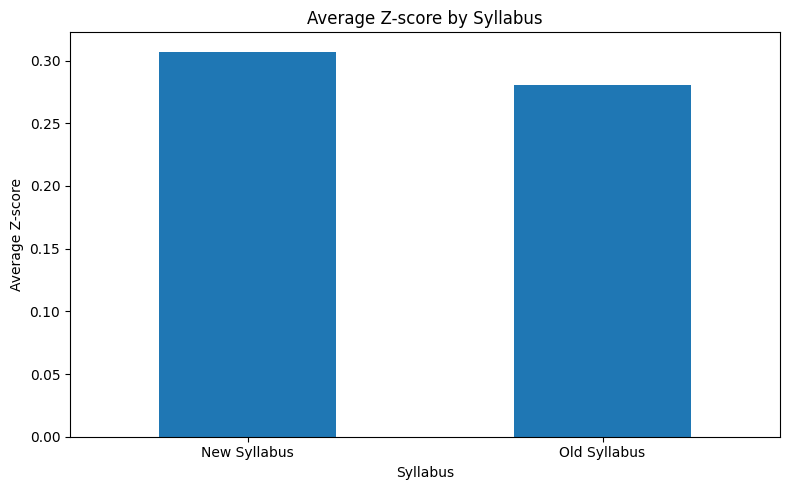

In [12]:
syllabus_chart = olap_df.groupby('syllabus_name')['z_score'].mean()

plt.figure(figsize=(8, 5))
syllabus_chart.plot(kind='bar')
plt.title('Average Z-score by Syllabus')
plt.xlabel('Syllabus')
plt.ylabel('Average Z-score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

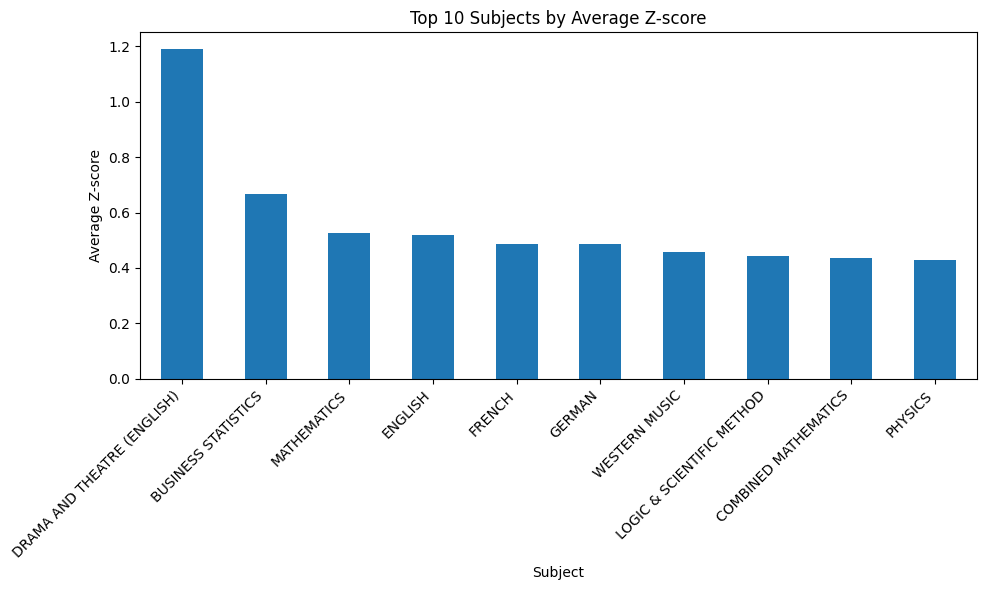

In [13]:
subject_chart = (
    olap_df.groupby('subject_name')['z_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
subject_chart.plot(kind='bar')
plt.title('Top 10 Subjects by Average Z-score')
plt.xlabel('Subject')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [15]:
# ============================================
# OLAP CUBE
# Dimensions:
#   Stream × Subject × Syllabus
# Measure:
#   Average Z-score
# ============================================

cube = olap_df.pivot_table(
    index='stream_name',
    columns=['subject_name', 'syllabus_name'],
    values='z_score',
    aggfunc='mean'
)

print("OLAP Cube created successfully.")
print("Number of Streams:", olap_df['stream_name'].nunique())
print("Number of Subjects:", olap_df['subject_name'].nunique())
print("Number of Syllabus Types:", olap_df['syllabus_name'].nunique())

display(cube.head())

OLAP Cube created successfully.
Number of Streams: 8
Number of Subjects: 62
Number of Syllabus Types: 2


subject_name             ACCOUNTING              AGRICULTURAL SCIENCE  \
syllabus_name          New Syllabus Old Syllabus         New Syllabus   
stream_name                                                             
ARTS                       0.272855     0.084400             0.494807   
BIOLOGICAL SCIENCE              NaN          NaN             0.420195   
BIOSYSTEMS TECHNOLOGY      0.857300          NaN             0.490985   
COMMERCE                   0.494503     0.655889             0.556780   
ENGINEERING TECHNOLOGY     0.601456          NaN             0.260880   

subject_name                        AGRO TECHNOLOGY                    ARABIC  \
syllabus_name          Old Syllabus    New Syllabus Old Syllabus New Syllabus   
stream_name                                                                     
ARTS                       0.336200         0.52568     0.284221     0.509826   
BIOLOGICAL SCIENCE         0.116601             NaN          NaN          NaN   
BIOSYSTEMS TECHNOLOGY      0.430225             NaN          NaN          NaN   
COMMERCE                   0.974600             NaN          NaN          NaN   
ENGINEERING TECHNOLOGY     0.392207             NaN          NaN          NaN   

subject_name                                 ART               ...  \
syllabus_name          Old Syllabus New Syllabus Old Syllabus  ...   
stream_name                                                    ...   
ARTS                       0.520633     0.327864      0.32264  ...   
BIOLOGICAL SCIENCE              NaN          NaN          NaN  ...   
BIOSYSTEMS TECHNOLOGY           NaN     0.509905      1.42320  ...   
COMMERCE                        NaN          NaN          NaN  ...   
ENGINEERING TECHNOLOGY          NaN     0.216899      0.10330  ...   

subject_name               SANSKRIT              SCIENCE FOR TECHNOLOGY  \
syllabus_name          New Syllabus Old Syllabus           New Syllabus   
stream_name                                                               
ARTS                        0.51633     0.647664                    NaN   
BIOLOGICAL SCIENCE              NaN          NaN                    NaN   
BIOSYSTEMS TECHNOLOGY           NaN          NaN               0.489908   
COMMERCE                        NaN          NaN                    NaN   
ENGINEERING TECHNOLOGY          NaN          NaN               0.462836   

subject_name                             SINHALA                     TAMIL  \
syllabus_name          Old Syllabus New Syllabus Old Syllabus New Syllabus   
stream_name                                                                  
ARTS                            NaN     0.465493     0.497721     0.386457   
BIOLOGICAL SCIENCE              NaN          NaN          NaN          NaN   
BIOSYSTEMS TECHNOLOGY      0.438325          NaN          NaN          NaN   
COMMERCE                        NaN          NaN          NaN          NaN   
ENGINEERING TECHNOLOGY     0.488243          NaN          NaN          NaN   

subject_name                        WESTERN MUSIC               
syllabus_name          Old Syllabus  New Syllabus Old Syllabus  
stream_name                                                     
ARTS                       0.367847      0.686107       0.7947  
BIOLOGICAL SCIENCE              NaN           NaN          NaN  
BIOSYSTEMS TECHNOLOGY           NaN           NaN          NaN  
COMMERCE                        NaN           NaN          NaN  
ENGINEERING TECHNOLOGY          NaN           NaN          NaN  

[5 rows x 115 columns]

In [17]:
# ============================================
# OLAP ROLL-UP
# Subject → Stream
# ============================================

rollup = olap_df.pivot_table(
    index='stream_name',
    columns='syllabus_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP ROLL-UP")
display(rollup.round(4))

OLAP ROLL-UP


syllabus_name,New Syllabus,Old Syllabus
stream_name,,
ARTS,0.4727,0.4527
BIOLOGICAL SCIENCE,0.6233,0.5259
BIOSYSTEMS TECHNOLOGY,0.4899,0.4383
COMMERCE,0.4942,0.6491
ENGINEERING TECHNOLOGY,0.4628,0.4882
Non Stream,0.4804,0.3536
PHYSICAL SCIENCE,0.6521,0.4375
Unknown,-0.5606,-0.5498


In [18]:
# ============================================
# OLAP DRILL-DOWN
# Stream → Subject
# ============================================

drilldown = olap_df.pivot_table(
    index=['stream_name', 'subject_name'],
    values='z_score',
    aggfunc=['count', 'mean']
)

drilldown.columns = ['result_count', 'average_z_score']

drilldown['average_z_score'] = drilldown['average_z_score'].round(4)

print("OLAP DRILL-DOWN")
display(drilldown)

OLAP DRILL-DOWN


result_count  average_z_score
stream_name subject_name                                         
ARTS        ACCOUNTING                        23           0.2647
            AGRICULTURAL SCIENCE            2997           0.4798
            AGRO TECHNOLOGY                  373           0.4758
            ARABIC                          1571           0.5112
            ART                             3625           0.3275
...                                          ...              ...
Unknown     SANSKRIT                         101          -0.6280
            SCIENCE FOR TECHNOLOGY          5712          -0.5323
            SINHALA                        10932          -0.6533
            TAMIL                           3111          -0.6656
            WESTERN MUSIC                     12          -0.5662

[218 rows x 2 columns]

In [19]:
# ============================================
# OLAP SLICE
# New Syllabus only
# ============================================

slice_new = olap_df[
    olap_df['syllabus_name'] == 'New Syllabus'
]

slice_result = slice_new.pivot_table(
    index='stream_name',
    columns='subject_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP SLICE - NEW SYLLABUS")
display(slice_result.round(4))

OLAP SLICE - NEW SYLLABUS


subject_name,ACCOUNTING,AGRICULTURAL SCIENCE,AGRO TECHNOLOGY,ARABIC,ART,BIO SYSTEMS TECHNOLOGY,BIO-RESOURCE TECHNOLOGY,BIOLOGY,BUDDHISM,BUDDHIST CIVILIZATION,...,ORIENTAL MUSIC,PALI,PHYSICS,POLITICAL SCIENCE,RUSSIAN,SANSKRIT,SCIENCE FOR TECHNOLOGY,SINHALA,TAMIL,WESTERN MUSIC
stream_name,,,,,,,,,,,,,,,,,,,,,
ARTS,0.2729,0.4948,0.5257,0.5098,0.3279,NaN,0.4059,NaN,0.3576,0.4626,...,0.4564,0.3686,NaN,0.5084,0.2982,0.5163,NaN,0.4655,0.3865,0.6861
BIOLOGICAL SCIENCE,NaN,0.4202,NaN,NaN,NaN,NaN,NaN,0.6233,NaN,NaN,...,NaN,NaN,0.6355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIOSYSTEMS TECHNOLOGY,0.8573,0.4910,NaN,NaN,0.5099,0.4899,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4899,NaN,NaN,NaN
COMMERCE,0.4945,0.5568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.3136,NaN,NaN,NaN,NaN,NaN,NaN
ENGINEERING TECHNOLOGY,0.6015,0.2609,NaN,NaN,0.2169,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4628,NaN,NaN,NaN
Non Stream,0.8282,0.3832,0.4363,-0.0978,-0.0462,0.1107,NaN,0.4557,0.0038,0.0337,...,-0.0095,-0.1977,0.6341,0.1537,-0.0418,0.0737,0.4628,0.0177,0.0349,0.2080
PHYSICAL SCIENCE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.6521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unknown,-0.6609,-0.4492,-0.4397,-0.6310,-0.7088,-0.5733,-0.1841,-0.3957,-0.7191,-0.6417,...,-0.7080,-0.7421,-0.4182,-0.6112,-0.9383,-0.6265,-0.5367,-0.6489,-0.6764,-0.5662


In [20]:
# ============================================
# OLAP DICE
# Selected Streams + Subjects + New Syllabus
# ============================================

selected_streams = [
    'ARTS',
    'COMMERCE'
]

selected_subjects = [
    'ACCOUNTING',
    'ECONOMICS',
    'BUSINESS STUDIES'
]

dice_data = olap_df[
    olap_df['stream_name'].isin(selected_streams) &
    olap_df['subject_name'].isin(selected_subjects) &
    (olap_df['syllabus_name'] == 'New Syllabus')
]

dice_result = dice_data.groupby(
    ['stream_name', 'subject_name']
).agg(
    result_count=('z_score', 'count'),
    average_z_score=('z_score', 'mean')
).reset_index()

dice_result['average_z_score'] = dice_result['average_z_score'].round(4)

print("OLAP DICE")
display(dice_result)

OLAP DICE


,stream_name,subject_name,result_count,average_z_score
0,ARTS,ACCOUNTING,22,0.2729
1,ARTS,ECONOMICS,4595,0.6717
2,COMMERCE,ACCOUNTING,39135,0.4945
3,COMMERCE,BUSINESS STUDIES,37210,0.4829
4,COMMERCE,ECONOMICS,36945,0.4945


In [21]:
# ============================================
# OLAP PIVOT
# Subject × Stream
# ============================================

pivot_result = olap_df.pivot_table(
    index='subject_name',
    columns='stream_name',
    values='z_score',
    aggfunc='mean'
)

print("OLAP PIVOT")
display(pivot_result.round(4))

OLAP PIVOT


stream_name,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,Non Stream,PHYSICAL SCIENCE,Unknown
subject_name,,,,,,,,
ACCOUNTING,0.2647,NaN,0.8573,0.4972,0.6015,0.7908,NaN,-0.6522
AGRICULTURAL SCIENCE,0.4798,0.3105,0.4877,0.6762,0.2641,0.3496,NaN,-0.4619
AGRO TECHNOLOGY,0.4758,NaN,NaN,NaN,NaN,0.3246,NaN,-0.4818
ARABIC,0.5112,NaN,NaN,NaN,NaN,-0.0694,NaN,-0.6003
ART,0.3275,NaN,0.5496,NaN,0.2140,-0.0208,NaN,-0.7096
...,...,...,...,...,...,...,...,...
SANSKRIT,0.5197,NaN,NaN,NaN,NaN,0.0737,NaN,-0.6280
SCIENCE FOR TECHNOLOGY,NaN,NaN,0.4875,NaN,0.4636,0.5103,NaN,-0.5323
SINHALA,0.4676,NaN,NaN,NaN,NaN,0.0219,NaN,-0.6533


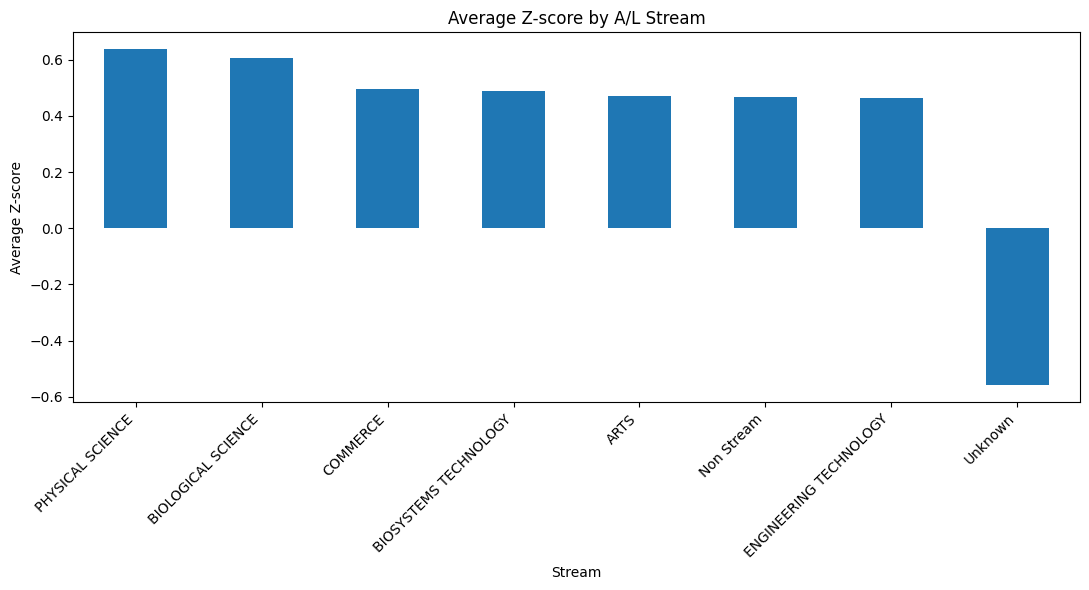

In [22]:
# ============================================
# VISUALIZATION 1
# Average Z-score by Stream
# ============================================

stream_chart = (
    olap_df.groupby('stream_name')['z_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

stream_chart.plot(kind='bar')

plt.title('Average Z-score by A/L Stream')
plt.xlabel('Stream')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

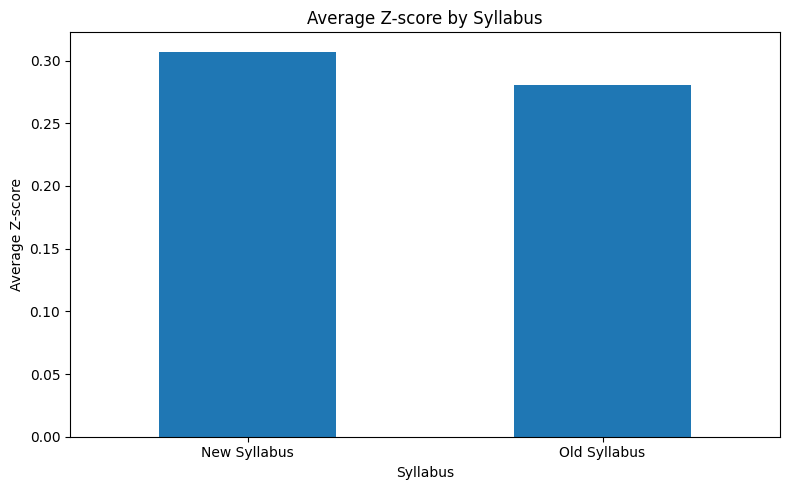

In [23]:
# ============================================
# VISUALIZATION 2
# Average Z-score by Syllabus
# ============================================

syllabus_chart = (
    olap_df.groupby('syllabus_name')['z_score']
    .mean()
)

plt.figure(figsize=(8, 5))

syllabus_chart.plot(kind='bar')

plt.title('Average Z-score by Syllabus')
plt.xlabel('Syllabus')
plt.ylabel('Average Z-score')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

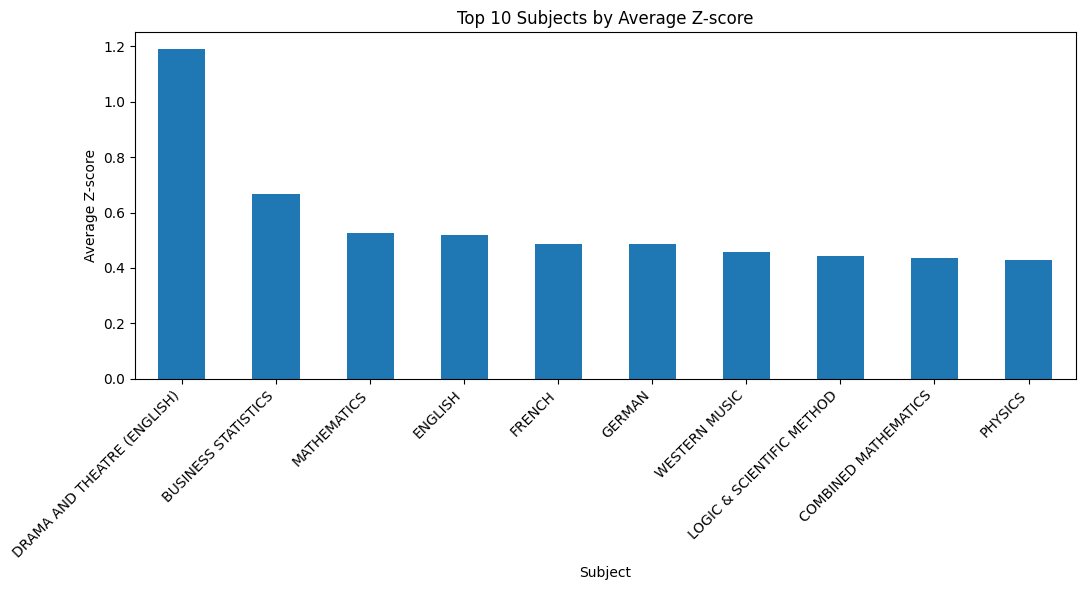

In [24]:
# ============================================
# VISUALIZATION 3
# Top 10 Subjects by Average Z-score
# ============================================

subject_chart = (
    olap_df.groupby('subject_name')['z_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))

subject_chart.plot(kind='bar')

plt.title('Top 10 Subjects by Average Z-score')
plt.xlabel('Subject')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

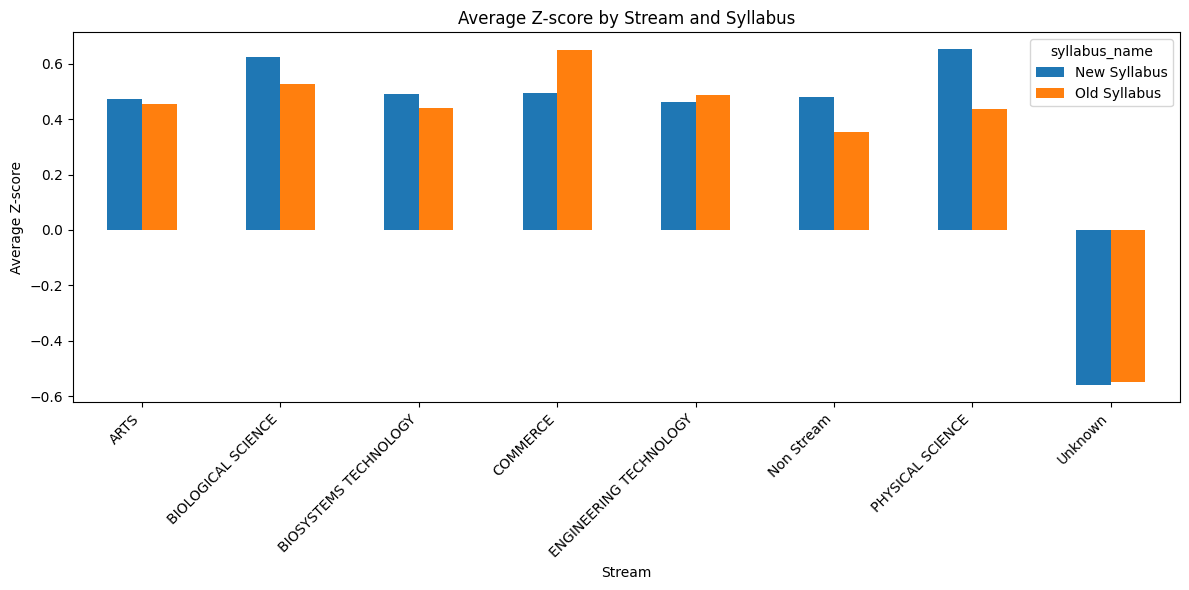

In [25]:
# ============================================
# VISUALIZATION 4
# Stream × Syllabus
# ============================================

stream_syllabus = olap_df.pivot_table(
    index='stream_name',
    columns='syllabus_name',
    values='z_score',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))

stream_syllabus.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Z-score by Stream and Syllabus')
plt.xlabel('Stream')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# KEY FINDINGS
# ============================================

stream_avg = (
    olap_df.groupby('stream_name')['z_score']
    .mean()
    .sort_values(ascending=False)
)

subject_avg = (
    olap_df.groupby('subject_name')['z_score']
    .mean()
    .sort_values(ascending=False)
)

syllabus_avg = (
    olap_df.groupby('syllabus_name')['z_score']
    .mean()
    .sort_values(ascending=False)
)

highest_stream = stream_avg.index[0]
highest_stream_score = stream_avg.iloc[0]

highest_subject = subject_avg.index[0]
highest_subject_score = subject_avg.iloc[0]

print("KEY FINDINGS")
print("=" * 50)

print(
    f"1. Highest average Z-score stream: "
    f"{highest_stream} ({highest_stream_score:.4f})"
)

print(
    f"2. Highest average Z-score subject: "
    f"{highest_subject} ({highest_subject_score:.4f})"
)

print(
    f"3. Highest performing syllabus: "
    f"{syllabus_avg.index[0]} ({syllabus_avg.iloc[0]:.4f})"
)

print(
    f"4. Number of streams analyzed: "
    f"{olap_df['stream_name'].nunique()}"
)

print(
    f"5. Number of subjects analyzed: "
    f"{olap_df['subject_name'].nunique()}"
)

print(
    f"6. Number of syllabus types analyzed: "
    f"{olap_df['syllabus_name'].nunique()}"
)

KEY FINDINGS
1. Highest average Z-score stream: PHYSICAL SCIENCE (0.6380)
2. Highest average Z-score subject: DRAMA AND THEATRE (ENGLISH) (1.1911)
3. Highest performing syllabus: New Syllabus (0.3072)
4. Number of streams analyzed: 8
5. Number of subjects analyzed: 62
6. Number of syllabus types analyzed: 2


In [27]:
# ============================================
# GENERATE OLAP REPORT
# ============================================

from IPython.display import HTML

report = f"""
<!DOCTYPE html>

<html>

<head>

<title>Day04 OLAP Analysis Report</title>

<style>

body {{
    font-family: Arial, sans-serif;
    margin: 40px;
    line-height: 1.6;
}}

h1 {{
    text-align: center;
}}

h2 {{
    border-bottom: 2px solid #333;
    padding-bottom: 5px;
}}

table {{
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 25px;
}}

th, td {{
    border: 1px solid #999;
    padding: 8px;
    text-align: left;
}}

th {{
    font-weight: bold;
}}

.info {{
    padding: 15px;
    border: 1px solid #999;
    margin-bottom: 20px;
}}

</style>

</head>

<body>

<h1>Data Warehousing & OLAP Analysis</h1>

<h2>G.C.E. Advanced Level 2020 Dataset</h2>

<div class="info">

<b>Student Index No:</b> GAHDSE252F-006<br>

<b>Module:</b> Data Warehousing<br>

<b>Database:</b> PostgreSQL 18<br>

<b>OLAP Tool:</b> Google Colab / Python / Pandas<br>

<b>Fact Records:</b> 1,012,659

</div>


<h2>1. Introduction</h2>

<p>
This report presents the implementation of an Online Analytical Processing
(OLAP) cube using the Sri Lankan G.C.E. Advanced Level 2020 examination
dataset. The data warehouse was implemented using a star schema in
PostgreSQL, while Google Colab and Python were used for multidimensional
analysis.
</p>


<h2>2. OLAP Cube Design</h2>

<p>
The OLAP cube uses three main dimensions:
</p>

<ul>
<li>Stream</li>
<li>Subject</li>
<li>Syllabus</li>
</ul>

<p>
The primary measure is Average Z-score, with Result Count used as an
additional analytical measure.
</p>

<p>
<b>Cube:</b> Stream × Subject × Syllabus
</p>


<h2>3. Roll-up</h2>

<p>
Roll-up summarizes data from a detailed level to a higher aggregation level.
In this analysis, Subject-level information was aggregated to Stream level.
</p>

<h2>4. Drill-down</h2>

<p>
Drill-down moves from a higher-level summary to a more detailed level.
The analysis moved from Stream to individual Subject.
</p>

<h2>5. Slice</h2>

<p>
The Slice operation selected only the New Syllabus records from the cube.
This allowed performance to be analyzed using Stream and Subject dimensions
while keeping the Syllabus dimension fixed.
</p>

<h2>6. Dice</h2>

<p>
The Dice operation selected multiple values from multiple dimensions.
The analysis selected ARTS and COMMERCE streams, ACCOUNTING, ECONOMICS
and BUSINESS STUDIES subjects, and New Syllabus.
</p>

<h2>7. Pivot</h2>

<p>
The Pivot operation changed the orientation of the analytical view.
Subject was placed on rows and Stream was placed on columns.
</p>


<h2>8. Key Findings</h2>

<ul>

<li>
Highest average Z-score stream:
<b>{highest_stream}</b>
({highest_stream_score:.4f})
</li>

<li>
Highest average Z-score subject:
<b>{highest_subject}</b>
({highest_subject_score:.4f})
</li>

<li>
Number of streams analyzed:
<b>{olap_df['stream_name'].nunique()}</b>
</li>

<li>
Number of subjects analyzed:
<b>{olap_df['subject_name'].nunique()}</b>
</li>

<li>
Number of syllabus types:
<b>{olap_df['syllabus_name'].nunique()}</b>
</li>

</ul>


<h2>9. Conclusion</h2>

<p>
The OLAP implementation successfully provided a multidimensional analytical
view of the G.C.E. Advanced Level 2020 examination data. The Stream, Subject
and Syllabus dimensions enabled different levels of analysis through
Roll-up, Drill-down, Slice, Dice and Pivot operations. The resulting
analysis can be used to identify performance patterns across streams,
subjects and syllabus types.
</p>


<h2>10. Evidence</h2>

<p>
Screenshots from the Google Colab notebook should be attached to the
submission to demonstrate the execution of the OLAP cube and each
analytical operation.
</p>

</body>

</html>
"""

with open("Day04_OLAP_Report.html", "w", encoding="utf-8") as f:
    f.write(report)

print("Report generated successfully!")

Report generated successfully!


In [28]:
from google.colab import files

files.download("Day04_OLAP_Report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.8 MB/s eta 0:00:00


In [30]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    PageBreak, Image
)
import matplotlib.pyplot as plt
import os

# ============================================
# PDF FILE
# ============================================

pdf_file = "Day04_OLAP_Report.pdf"

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=1.5*cm,
    leftMargin=1.5*cm,
    topMargin=1.5*cm,
    bottomMargin=1.5*cm
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleCustom",
    parent=styles["Title"],
    fontSize=22,
    alignment=TA_CENTER,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingCustom",
    parent=styles["Heading1"],
    fontSize=16,
    spaceBefore=12,
    spaceAfter=8
)

subheading_style = ParagraphStyle(
    "SubHeadingCustom",
    parent=styles["Heading2"],
    fontSize=12,
    spaceBefore=8,
    spaceAfter=6
)

body_style = ParagraphStyle(
    "BodyCustom",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=14,
    spaceAfter=7
)

story = []


# ============================================
# TITLE PAGE
# ============================================

story.append(Spacer(1, 2*cm))

story.append(
    Paragraph(
        "DATA WAREHOUSING & OLAP ANALYSIS",
        title_style
    )
)

story.append(
    Paragraph(
        "G.C.E. Advanced Level 2020 Dataset",
        styles["Heading2"]
    )
)

story.append(Spacer(1, 1*cm))

details = [
    ["Student Index No.", "GAHDSE252F-006"],
    ["Module", "Data Warehousing"],
    ["Database", "PostgreSQL 18"],
    ["Warehouse", "AL_DataWarehouse"],
    ["OLAP Tool", "Google Colab / Python / Pandas"],
    ["Fact Records", "1,012,659"],
]

table = Table(details, colWidths=[6*cm, 9*cm])

table.setStyle(TableStyle([
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("BACKGROUND", (0,0), (0,-1), colors.lightgrey),
    ("FONTNAME", (0,0), (0,-1), "Helvetica-Bold"),
    ("FONTSIZE", (0,0), (-1,-1), 9),
    ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
    ("TOPPADDING", (0,0), (-1,-1), 8),
    ("BOTTOMPADDING", (0,0), (-1,-1), 8),
]))

story.append(table)

story.append(Spacer(1, 2*cm))

story.append(
    Paragraph(
        "Day 04 – OLAP Cube Implementation",
        styles["Heading2"]
    )
)

story.append(PageBreak())


# ============================================
# 1. INTRODUCTION
# ============================================

story.append(
    Paragraph("1. Introduction", heading_style)
)

story.append(
    Paragraph(
        "This report presents the implementation of an Online Analytical "
        "Processing (OLAP) cube using the Sri Lankan G.C.E. Advanced Level "
        "2020 examination dataset. The data warehouse was implemented using "
        "PostgreSQL and a star schema, while Google Colab, Python and Pandas "
        "were used to perform multidimensional OLAP analysis.",
        body_style
    )
)


# ============================================
# 2. DATA WAREHOUSE
# ============================================

story.append(
    Paragraph("2. Data Warehouse Overview", heading_style)
)

story.append(
    Paragraph(
        "The warehouse consists of a central fact table and several "
        "dimension tables. The grain of the fact table is one student's "
        "result for one subject in the examination.",
        body_style
    )
)

warehouse_data = [
    ["Table", "Records"],
    ["fact_student_performance", "1,012,659"],
    ["dim_student", "337,553"],
    ["dim_subject", "62"],
    ["dim_stream", "8"],
    ["dim_syllabus", "2"],
    ["dim_exam", "1"],
    ["dim_gender", "3"]
]

table = Table(
    warehouse_data,
    colWidths=[10*cm, 5*cm]
)

table.setStyle(TableStyle([
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("ALIGN", (1,1), (1,-1), "RIGHT"),
    ("FONTSIZE", (0,0), (-1,-1), 9),
    ("TOPPADDING", (0,0), (-1,-1), 6),
    ("BOTTOMPADDING", (0,0), (-1,-1), 6),
]))

story.append(table)


# ============================================
# 3. OLAP CUBE
# ============================================

story.append(
    Paragraph("3. OLAP Cube Design", heading_style)
)

story.append(
    Paragraph(
        "The OLAP cube was designed using three main dimensions: Stream, "
        "Subject and Syllabus. Average Z-score is used as the main analytical "
        "measure and result count is used as an additional measure.",
        body_style
    )
)

cube_data = [
    ["Component", "Description"],
    ["Dimension 1", "Stream"],
    ["Dimension 2", "Subject"],
    ["Dimension 3", "Syllabus"],
    ["Measure 1", "Average Z-score"],
    ["Measure 2", "Result Count"]
]

table = Table(
    cube_data,
    colWidths=[6*cm, 9*cm]
)

table.setStyle(TableStyle([
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("FONTSIZE", (0,0), (-1,-1), 9),
    ("TOPPADDING", (0,0), (-1,-1), 6),
    ("BOTTOMPADDING", (0,0), (-1,-1), 6),
]))

story.append(table)

story.append(
    Paragraph(
        "<b>Cube structure:</b> Stream × Subject × Syllabus → Average Z-score",
        body_style
    )
)


# ============================================
# 4. ROLL-UP
# ============================================

story.append(
    Paragraph("4. OLAP Roll-up", heading_style)
)

story.append(
    Paragraph(
        "Roll-up summarizes detailed data into a higher-level aggregation. "
        "In this implementation, subject-level information is aggregated "
        "to the stream level.",
        body_style
    )
)

story.append(
    Paragraph(
        "Result: Average Z-score by Stream and Syllabus.",
        body_style
    )
)


# ============================================
# 5. DRILL-DOWN
# ============================================

story.append(
    Paragraph("5. OLAP Drill-down", heading_style)
)

story.append(
    Paragraph(
        "Drill-down moves from a higher-level summary to a more detailed "
        "level. The analysis moves from Stream to individual Subject and "
        "calculates result count and average Z-score.",
        body_style
    )
)


# ============================================
# 6. SLICE
# ============================================

story.append(
    Paragraph("6. OLAP Slice", heading_style)
)

story.append(
    Paragraph(
        "The Slice operation selects one value from a dimension. "
        "New Syllabus was selected, allowing Stream and Subject performance "
        "to be analyzed while keeping Syllabus fixed.",
        body_style
    )
)


# ============================================
# 7. DICE
# ============================================

story.append(
    Paragraph("7. OLAP Dice", heading_style)
)

story.append(
    Paragraph(
        "The Dice operation selects multiple values from multiple dimensions. "
        "The analysis selected the ARTS and COMMERCE streams, ACCOUNTING, "
        "ECONOMICS and BUSINESS STUDIES subjects, and New Syllabus.",
        body_style
    )
)


# ============================================
# 8. PIVOT
# ============================================

story.append(
    Paragraph("8. OLAP Pivot", heading_style)
)

story.append(
    Paragraph(
        "The Pivot operation changes the orientation of the analytical view. "
        "Subject is placed on rows while Stream is placed on columns. "
        "The underlying data remains unchanged.",
        body_style
    )
)


# ============================================
# CALCULATE CHART DATA
# ============================================

stream_chart = (
    olap_df.groupby("stream_name")["z_score"]
    .mean()
    .sort_values(ascending=False)
)

syllabus_chart = (
    olap_df.groupby("syllabus_name")["z_score"]
    .mean()
)

subject_chart = (
    olap_df.groupby("subject_name")["z_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


# ============================================
# CREATE CHART 1
# ============================================

plt.figure(figsize=(9, 5))

stream_chart.plot(kind="bar")

plt.title("Average Z-score by A/L Stream")
plt.xlabel("Stream")
plt.ylabel("Average Z-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

chart1 = "stream_chart.png"
plt.savefig(chart1, dpi=200, bbox_inches="tight")
plt.close()


# ============================================
# CREATE CHART 2
# ============================================

plt.figure(figsize=(7, 5))

syllabus_chart.plot(kind="bar")

plt.title("Average Z-score by Syllabus")
plt.xlabel("Syllabus")
plt.ylabel("Average Z-score")
plt.xticks(rotation=0)
plt.tight_layout()

chart2 = "syllabus_chart.png"
plt.savefig(chart2, dpi=200, bbox_inches="tight")
plt.close()


# ============================================
# CREATE CHART 3
# ============================================

plt.figure(figsize=(9, 5))

subject_chart.plot(kind="bar")

plt.title("Top 10 Subjects by Average Z-score")
plt.xlabel("Subject")
plt.ylabel("Average Z-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

chart3 = "subject_chart.png"
plt.savefig(chart3, dpi=200, bbox_inches="tight")
plt.close()


# ============================================
# 9. VISUALIZATIONS
# ============================================

story.append(PageBreak())

story.append(
    Paragraph("9. OLAP Visualizations", heading_style)
)

story.append(
    Paragraph(
        "The following visualizations summarize important patterns identified "
        "through the OLAP analysis.",
        body_style
    )
)

story.append(
    Paragraph("9.1 Average Z-score by Stream", subheading_style)
)

story.append(Image(chart1, width=16*cm, height=9*cm))

story.append(Spacer(1, 0.5*cm))

story.append(
    Paragraph("9.2 Average Z-score by Syllabus", subheading_style)
)

story.append(Image(chart2, width=14*cm, height=9*cm))

story.append(PageBreak())

story.append(
    Paragraph("9.3 Top 10 Subjects by Average Z-score", subheading_style)
)

story.append(Image(chart3, width=16*cm, height=9*cm))


# ============================================
# 10. FINDINGS
# ============================================

story.append(PageBreak())

story.append(
    Paragraph("10. Key Findings", heading_style)
)

highest_stream = stream_chart.index[0]
highest_stream_score = stream_chart.iloc[0]

highest_subject = subject_chart.index[0]
highest_subject_score = subject_chart.iloc[0]

findings = [
    f"The stream with the highest average Z-score was "
    f"<b>{highest_stream}</b>, with an average Z-score of "
    f"<b>{highest_stream_score:.4f}</b>.",

    f"The highest average Z-score among the top 10 subjects was "
    f"<b>{highest_subject}</b>, with a value of "
    f"<b>{highest_subject_score:.4f}</b>.",

    "The OLAP cube contains 8 streams, 62 subjects and 2 syllabus types.",

    "Roll-up provides higher-level summaries, while drill-down provides "
    "more detailed subject-level analysis.",

    "Slice and Dice allow specific portions of the multidimensional data "
    "to be selected for focused analysis.",

    "Pivot allows the same analytical information to be viewed from a "
    "different dimensional orientation."
]

for finding in findings:
    story.append(
        Paragraph("• " + finding, body_style)
    )


# ============================================
# 11. CONCLUSION
# ============================================

story.append(
    Paragraph("11. Conclusion", heading_style)
)

story.append(
    Paragraph(
        "The OLAP implementation successfully transformed the PostgreSQL "
        "data warehouse into a multidimensional analytical environment. "
        "Stream, Subject and Syllabus were used as the main dimensions, "
        "while Average Z-score and Result Count provided analytical measures. "
        "The Roll-up, Drill-down, Slice, Dice and Pivot operations demonstrated "
        "how the examination dataset can be analyzed from different perspectives. "
        "The visualizations further supported the identification of performance "
        "patterns across streams, subjects and syllabus types.",
        body_style
    )
)


# ============================================
# BUILD PDF
# ============================================

doc.build(story)

print("========================================")
print("PDF GENERATED SUCCESSFULLY")
print("========================================")
print("File:", pdf_file)
print("Size:", round(os.path.getsize(pdf_file) / 1024, 2), "KB")

PDF GENERATED SUCCESSFULLY
File: Day04_OLAP_Report.pdf
Size: 304.57 KB


In [31]:
from google.colab import files

files.download("Day04_OLAP_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>